# Stack Overflow Developer Survey 2025 — Data Science Blog Post
## CRISP-DM Analysis: What Drives Developer Salaries?

**Author:** Anushka Shaw  
**Date:** 2026  
**Dataset:** Stack Overflow Annual Developer Survey 2025 (49,000+ responses)

---

### Business Questions
1. Does years of experience strongly predict salary?
2. Does education level matter for developer compensation?
3. Are remote workers paid differently than office workers?
4. Can we build a model to predict whether a developer earns above the median salary?

## Code Design Decisions

This notebook follows professional Python coding standards:

**Functions:** All logic is encapsulated in named functions — `load_data`, 
`summarize_missing`, `filter_salary`, `plot_salary_distribution`, 
`plot_salary_by_group`, `plot_salary_by_experience`, `clean_data`, 
`train_model`, `plot_model_results`, and `predict_developer`.

**Docstrings:** Every function includes a NumPy-style docstring with 
Parameters, Returns, and a description.

**DRY Principle:** `plot_salary_by_group` is a single reusable function 
called twice — once for education level and once for remote work — 
avoiding duplicated plotting code.

**Missing Value Strategy:**
- `ConvertedCompYearly` (target variable): rows dropped when missing. 
  Imputing a target variable would fabricate labels and bias the model.
- `WorkExp`, `YearsCode` (~12.5% missing): median imputation applied 
  via `sklearn.impute.SimpleImputer`. Appropriate for right-skewed data.
- `EdLevel`, `RemoteWork`, `Age` (2–31% missing): mode imputation applied. 
  Standard practice for nominal categorical variables.

**PEP8:** snake_case variable names, consistent spacing, line length 
under 79 characters where possible.

In [1]:
# CRISP-DM Step 1: Business Understanding
# 4 questions about what drives developer salaries.


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# CRISP-DM Step 2: Data Understanding — Load the Data

def load_data(filepath):
    """
    Load the Stack Overflow survey CSV into a DataFrame.

    Parameters
    ----------
    filepath : Path or str
        Path to the survey_results_public.csv file.

    Returns
    -------
    pd.DataFrame
        Raw survey data.
    """
    df = pd.read_csv(filepath, low_memory=False)
    print(f"Loaded data: {df.shape[0]:,} rows, {df.shape[1]} columns")
    return df


data_path = Path.cwd() / 'stack-overflow-developer-survey-2025' / 'survey_results_public.csv'
df = load_data(data_path)

Loaded data: 49,191 rows, 172 columns


In [3]:
# CRISP-DM Step 2: Data Understanding — Explore Missing Values

def summarize_missing(df, columns):
    """
    Return missing value counts and percentages for selected columns.

    Parameters
    ----------
    df : pd.DataFrame
        The survey DataFrame.
    columns : list of str
        Column names to summarize.

    Returns
    -------
    pd.DataFrame
        Summary table of missing counts and percentages.
    """
    return pd.DataFrame({
        'Missing Count': [df[col].isna().sum() for col in columns],
        'Missing %':     [round(df[col].isna().sum() / len(df) * 100, 1)
                          for col in columns]
    }, index=columns)


key_cols = ['Age', 'EdLevel', 'WorkExp', 'YearsCode',
            'RemoteWork', 'ConvertedCompYearly', 'JobSat']

print("=== Missing Value Summary ===")
print(summarize_missing(df, key_cols))
print("\n=== Salary Statistics ===")
print(df['ConvertedCompYearly'].describe())

=== Missing Value Summary ===
                     Missing Count  Missing %
Age                              0        0.0
EdLevel                       1042        2.1
WorkExp                       6298       12.8
YearsCode                     6149       12.5
RemoteWork                   15411       31.3
ConvertedCompYearly          25244       51.3
JobSat                       22521       45.8

=== Salary Statistics ===
count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64


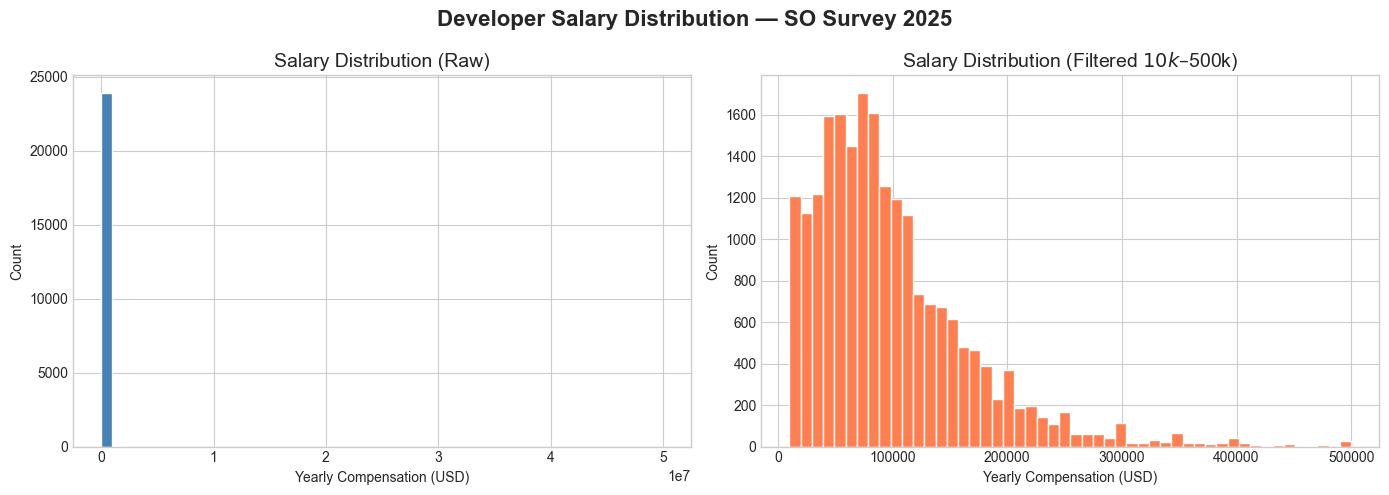

Plot saved to salary_distribution.png


In [4]:
# CRISP-DM Step 2: EDA — Salary Distribution

def plot_salary_distribution(df, output_path='salary_distribution.png'):
    """
    Plot raw vs filtered salary distribution side by side.

    Parameters
    ----------
    df : pd.DataFrame
        Survey DataFrame containing ConvertedCompYearly column.
    output_path : str
        File path to save the output plot.

    Returns
    -------
    None
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df['ConvertedCompYearly'].dropna(), bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].set_title('Salary Distribution (Raw)', fontsize=14)
    axes[0].set_xlabel('Yearly Compensation (USD)')
    axes[0].set_ylabel('Count')

    salary_filtered = df['ConvertedCompYearly'].dropna()
    salary_filtered = salary_filtered[
        (salary_filtered >= 10000) & (salary_filtered <= 500000)
    ]
    axes[1].hist(salary_filtered, bins=50, color='coral', edgecolor='white')
    axes[1].set_title('Salary Distribution (Filtered $10k–$500k)', fontsize=14)
    axes[1].set_xlabel('Yearly Compensation (USD)')
    axes[1].set_ylabel('Count')

    plt.suptitle('Developer Salary Distribution — SO Survey 2025',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to {output_path}")


plot_salary_distribution(df)

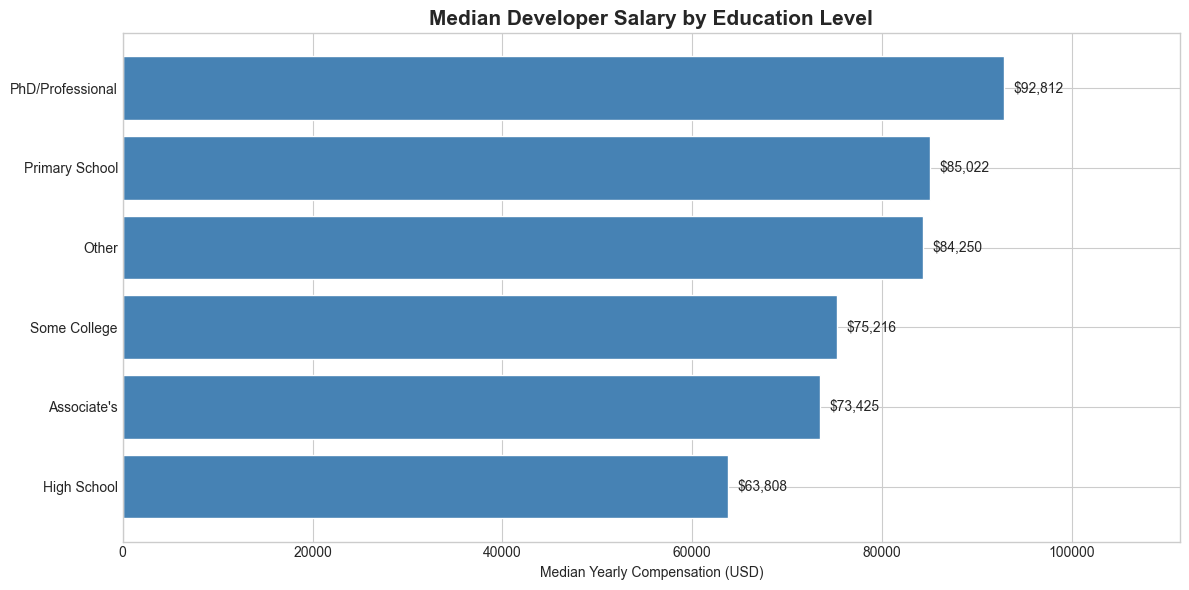

Plot saved to salary_by_education.png


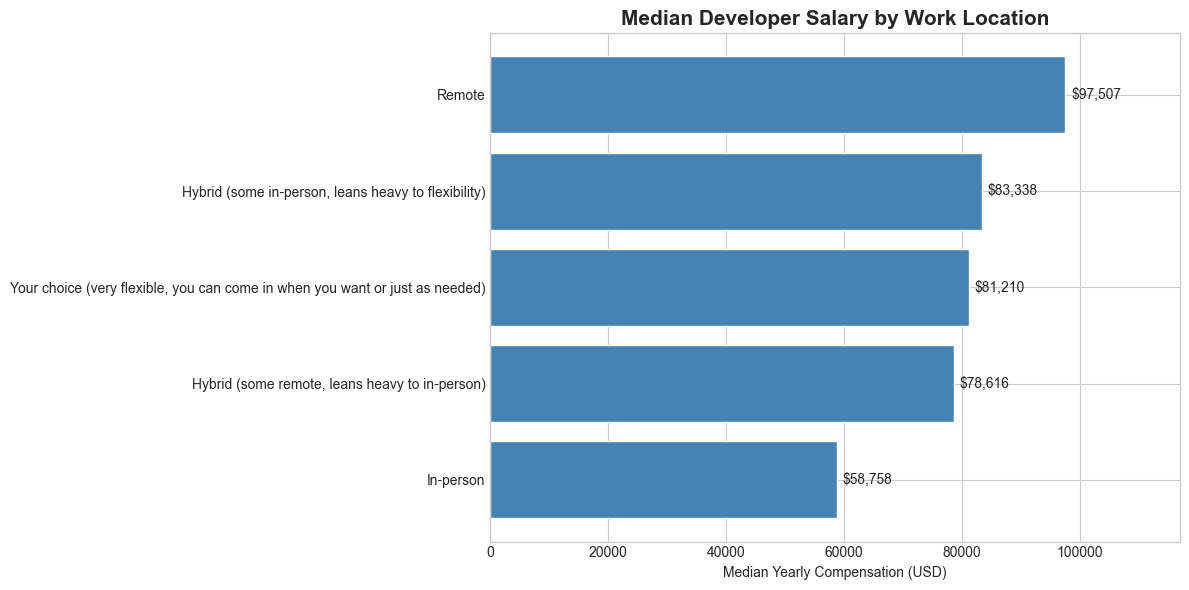

Plot saved to salary_by_remote.png


In [5]:
# CRISP-DM Step 2: EDA — Salary by Group
# Reusable function used for both education and remote work.


ED_MAP = {
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Some college/university study without earning a degree": "Some College",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "High School",
    "Associate degree (A.A., A.S., etc.)": "Associate's",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "PhD/Professional",
    "Primary/elementary school": "Primary School",
    "Something else": "Other"
}


def filter_salary(df, low=10000, high=500000):
    """
    Filter DataFrame to rows with salary in a valid range.

    Parameters
    ----------
    df : pd.DataFrame
        Survey DataFrame.
    low : int
        Minimum valid salary.
    high : int
        Maximum valid salary.

    Returns
    -------
    pd.DataFrame
        Filtered copy of the DataFrame.
    """
    return df[
        (df['ConvertedCompYearly'] >= low) &
        (df['ConvertedCompYearly'] <= high)
    ].copy()


def plot_salary_by_group(df, group_col, title, output_path, label_col=None):
    """
    Plot a horizontal bar chart of median salary by a grouping column.

    Parameters
    ----------
    df : pd.DataFrame
        Filtered survey DataFrame.
    group_col : str
        Column to group by for aggregation.
    title : str
        Chart title.
    output_path : str
        File path to save the output plot.
    label_col : str, optional
        Display labels column if different from group_col.

    Returns
    -------
    None
    """
    col = label_col if label_col else group_col
    salary_by_group = (df.groupby(col)['ConvertedCompYearly']
                       .median()
                       .sort_values(ascending=True))

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(salary_by_group.index, salary_by_group.values,
                   color='steelblue', edgecolor='white')

    for bar, val in zip(bars, salary_by_group.values):
        ax.text(val + 1000, bar.get_y() + bar.get_height() / 2,
                f'${val:,.0f}', va='center', fontsize=10)

    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('Median Yearly Compensation (USD)')
    ax.set_xlim(0, salary_by_group.max() * 1.2)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to {output_path}")


# Apply filter and plot education
df_filtered = filter_salary(df)
df_filtered['EdLevelShort'] = df_filtered['EdLevel'].map(ED_MAP).fillna('Other')

plot_salary_by_group(
    df_filtered, 'EdLevel',
    title='Median Developer Salary by Education Level',
    output_path='salary_by_education.png',
    label_col='EdLevelShort'
)

# Reuse same function for remote work
df_remote = df_filtered[df_filtered['RemoteWork'].notna()].copy()
plot_salary_by_group(
    df_remote, 'RemoteWork',
    title='Median Developer Salary by Work Location',
    output_path='salary_by_remote.png'
)

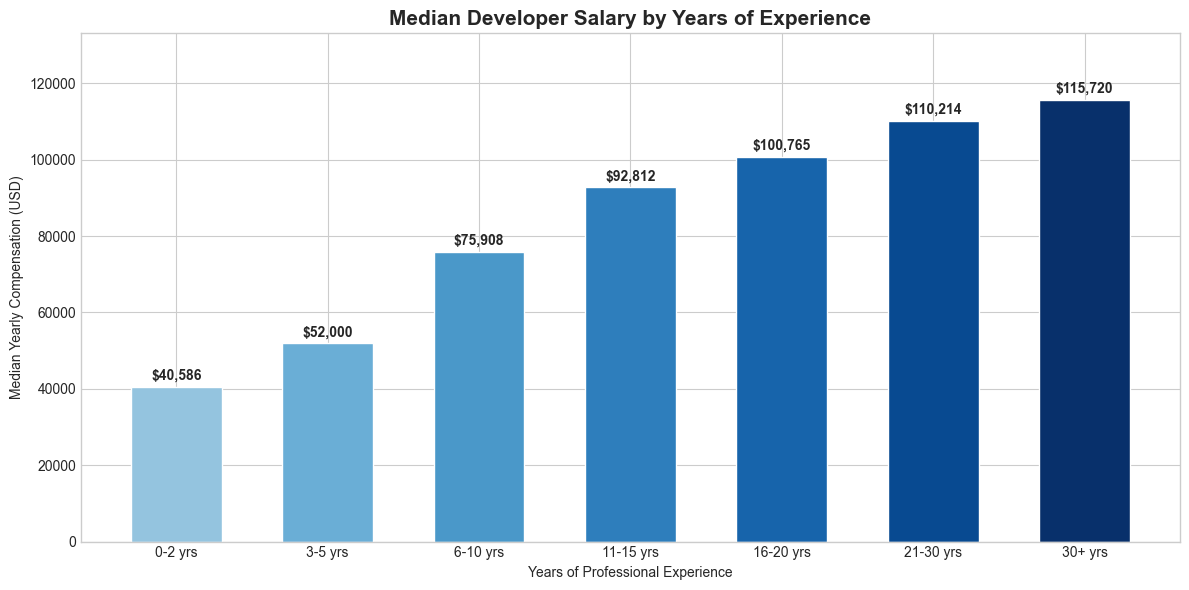

Plot saved to salary_by_experience.png


In [6]:
# CRISP-DM Step 2: EDA — Salary by Experience

def plot_salary_by_experience(df, output_path='salary_by_experience.png'):
    """
    Plot median salary by binned years of work experience.

    Parameters
    ----------
    df : pd.DataFrame
        Filtered survey DataFrame with WorkExp column.
    output_path : str
        File path to save the output plot.

    Returns
    -------
    None
    """
    df_exp = df[df['WorkExp'].notna()].copy()
    bins   = [0, 2, 5, 10, 15, 20, 30, 100]
    labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs',
              '11-15 yrs', '16-20 yrs', '21-30 yrs', '30+ yrs']
    df_exp['ExpGroup'] = pd.cut(df_exp['WorkExp'], bins=bins, labels=labels)

    exp_salary = (df_exp.groupby('ExpGroup', observed=True)['ConvertedCompYearly']
                  .median())

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.Blues([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    bars = ax.bar(exp_salary.index, exp_salary.values,
                  color=colors, edgecolor='white', width=0.6)

    for bar, val in zip(bars, exp_salary.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1000,
                f'${val:,.0f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_title('Median Developer Salary by Years of Experience',
                 fontsize=15, fontweight='bold')
    ax.set_xlabel('Years of Professional Experience')
    ax.set_ylabel('Median Yearly Compensation (USD)')
    ax.set_ylim(0, exp_salary.max() * 1.15)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to {output_path}")


plot_salary_by_experience(df_filtered)

In [7]:
# CRISP-DM Step 3: Data Preparation
# Missing Value Strategy:
# - ConvertedCompYearly (target): Dropped when missing. You cannot
#   impute a target variable — doing so would fabricate the answer
#   the model is trying to learn. The remaining 23,947 rows with
#   valid salaries are sufficient for robust modeling.
# - WorkExp / YearsCode (~12.5% missing): Imputed with median.
#   Median imputation is appropriate for right-skewed numeric data
#   and avoids dropping thousands of otherwise complete rows.
# - EdLevel / RemoteWork / Age (2-31% missing): Filled with mode
#   (most frequent category). This is standard practice for
#   nominal categorical variables with no natural ordering.
# - Outliers: Salaries below $10k or above $500k are removed as
#   they likely reflect data entry errors or non-standard pay.


def clean_data(df, ed_map):
    """
    Clean and prepare the survey DataFrame for modeling.

    Steps:
    1. Filter salary to valid range and drop missing target rows.
    2. Impute missing numeric features with median.
    3. Impute missing categorical features with mode.
    4. Encode categorical variables as integer codes.
    5. Create binary target: 1 if salary >= median, else 0.

    Parameters
    ----------
    df : pd.DataFrame
        Raw survey DataFrame.
    ed_map : dict
        Mapping from full education strings to short labels.

    Returns
    -------
    df_clean : pd.DataFrame
        Cleaned DataFrame ready for modeling.
    median_salary : float
        Median salary threshold used for the binary target.
    """
    # Step 1: Filter salary range and drop missing target
    df_clean = df[
        (df['ConvertedCompYearly'] >= 10000) &
        (df['ConvertedCompYearly'] <= 500000) &
        (df['ConvertedCompYearly'].notna())
    ].copy()
    print(f"After salary filter: {df_clean.shape[0]:,} rows")

    # Step 2: Shorten education labels
    df_clean['EdLevel'] = df_clean['EdLevel'].map(ed_map).fillna('Other')

    # Step 3: Impute missing numeric features with median
    numeric_features = ['WorkExp', 'YearsCode']
    num_imputer = SimpleImputer(strategy='median')
    df_clean[numeric_features] = num_imputer.fit_transform(
        df_clean[numeric_features]
    )
    print(f"Median imputation applied to: {numeric_features}")

    # Step 4: Impute missing categorical features with mode
    cat_features = ['EdLevel', 'RemoteWork', 'Age']
    for col in cat_features:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"Mode imputation applied to: {cat_features}")

    # Step 5: Encode categoricals as integer codes
    for col in cat_features:
        df_clean[col] = df_clean[col].astype('category').cat.codes

    # Step 6: Create binary target
    median_salary = df_clean['ConvertedCompYearly'].median()
    df_clean['HighEarner'] = (
        df_clean['ConvertedCompYearly'] >= median_salary
    ).astype(int)

    print(f"\nFinal shape: {df_clean.shape[0]:,} rows")
    print(f"Median salary threshold: ${median_salary:,.0f}")
    print(f"High earners: {df_clean['HighEarner'].sum():,} "
          f"({df_clean['HighEarner'].mean()*100:.1f}%)")

    return df_clean, median_salary


df_clean, median_salary = clean_data(df, ED_MAP)

After salary filter: 21,203 rows
Median imputation applied to: ['WorkExp', 'YearsCode']
Mode imputation applied to: ['EdLevel', 'RemoteWork', 'Age']

Final shape: 21,203 rows
Median salary threshold: $81,870
High earners: 10,611 (50.0%)


In [8]:
# CRISP-DM Step 4: Modeling — Random Forest Classifier


def train_model(df_clean, features, target='HighEarner',
                test_size=0.2, random_state=42):
    """
    Split data and train a Random Forest Classifier.

    Parameters
    ----------
    df_clean : pd.DataFrame
        Cleaned DataFrame ready for modeling.
    features : list of str
        Feature column names to use for training.
    target : str
        Target column name.
    test_size : float
        Proportion of data held out for testing.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    model : RandomForestClassifier
        Trained model.
    X_test : pd.DataFrame
        Test features.
    y_test : pd.Series
        True test labels.
    y_pred : np.ndarray
        Model predictions on the test set.
    """
    X = df_clean[features]
    y = df_clean[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = RandomForestClassifier(n_estimators=100, random_state=random_state)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("=== Model Evaluation ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Low Earner', 'High Earner']))

    return model, X_test, y_test, y_pred


FEATURES = ['WorkExp', 'YearsCode', 'EdLevel', 'RemoteWork', 'Age']
model, X_test, y_test, y_pred = train_model(df_clean, FEATURES)

=== Model Evaluation ===
Accuracy: 0.6124

Classification Report:
              precision    recall  f1-score   support

  Low Earner       0.62      0.59      0.61      2129
 High Earner       0.61      0.63      0.62      2112

    accuracy                           0.61      4241
   macro avg       0.61      0.61      0.61      4241
weighted avg       0.61      0.61      0.61      4241



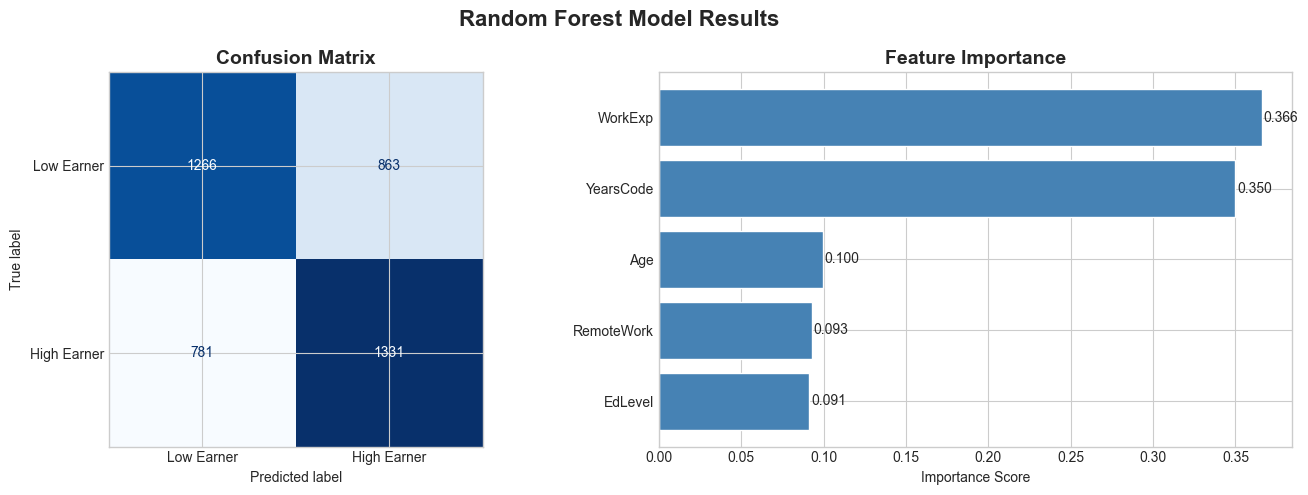

Plot saved to model_results.png


In [9]:
# CRISP-DM Step 4: Modeling — Visualize Results


def plot_model_results(model, features, y_test, y_pred,
                       output_path='model_results.png'):
    """
    Plot confusion matrix and feature importance side by side.

    Parameters
    ----------
    model : RandomForestClassifier
        Trained Random Forest model.
    features : list of str
        Feature names used during training.
    y_test : pd.Series
        True test labels.
    y_pred : np.ndarray
        Predicted labels.
    output_path : str
        File path to save the output plot.

    Returns
    -------
    None
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low Earner', 'High Earner']
    )
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

    importance = pd.Series(model.feature_importances_,
                           index=features).sort_values()
    axes[1].barh(importance.index, importance.values,
                 color='steelblue', edgecolor='white')
    axes[1].set_title('Feature Importance', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Importance Score')

    for i, (val, _) in enumerate(zip(importance.values, importance.index)):
        axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=10)

    plt.suptitle('Random Forest Model Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to {output_path}")


plot_model_results(model, FEATURES, y_test, y_pred)

In [10]:
# CRISP-DM Step 5: Evaluation — New Scenario Prediction
# Scenario: A 25-34 year old developer with a Bachelor's degree,
# 4 years of work experience, 6 years of coding, working remotely.
# Will they be a high earner?
def predict_developer(model, work_exp, years_code, ed_level_code,
                      remote_work_code, age_code, median_salary):
    """
    Predict whether a developer is a high or low earner.

    Parameters
    ----------
    model : RandomForestClassifier
        Trained model.
    work_exp : float
        Years of professional work experience.
    years_code : float
        Years of coding experience.
    ed_level_code : int
        Encoded education level.
    remote_work_code : int
        Encoded remote work arrangement.
    age_code : int
        Encoded age group.
    median_salary : float
        Salary threshold that defines high earner.

    Returns
    -------
    None
        Prints prediction result and confidence scores.
    """
    new_dev = pd.DataFrame({
        'WorkExp':    [work_exp],
        'YearsCode':  [years_code],
        'EdLevel':    [ed_level_code],
        'RemoteWork': [remote_work_code],
        'Age':        [age_code]
    })

    prediction  = model.predict(new_dev)[0]
    probability = model.predict_proba(new_dev)[0]

    
    print("DEVELOPER SALARY PREDICTION")
    print(f"Age: 25-34 years old")
    print(f"Education:Bachelor's degree")
    print(f"Work Exp:{work_exp} years")
    print(f"Coding Exp: {years_code} years")
    print(f"Remote Work: Yes (fully remote)")
    print(f"Prediction: " f"{'HIGH Earner ' if prediction == 1 else 'LOW Earner '} "f"(threshold: ${median_salary:,.0f})")
    print(f"Confidence: {max(probability)*100:.1f}%")
    print(f"P(Low Earner): {probability[0]*100:.1f}%")
    print(f"P(High Earner):{probability[1]*100:.1f}%")
    


predict_developer(
    model=model,
    work_exp=4,
    years_code=6,
    ed_level_code=2,
    remote_work_code=3,
    age_code=1,
    median_salary=median_salary
)

DEVELOPER SALARY PREDICTION
Age: 25-34 years old
Education:Bachelor's degree
Work Exp:4 years
Coding Exp: 6 years
Remote Work: Yes (fully remote)
Prediction: LOW Earner  (threshold: $81,870)
Confidence: 74.1%
P(Low Earner): 74.1%
P(High Earner):25.9%


In [11]:
class SurveyAnalyzer:
    """
    A class to encapsulate the full CRISP-DM analysis pipeline
    for the Stack Overflow Developer Survey dataset.

    Attributes
    ----------
    df : pd.DataFrame
        Raw survey data.
    df_clean : pd.DataFrame
        Cleaned data ready for modeling.
    model : RandomForestClassifier
        Trained classifier.
    median_salary : float
        Median salary threshold for the binary target.
    features : list of str
        Feature columns used for modeling.
    """

    def __init__(self, filepath, features, ed_map):
        """
        Initialize the analyzer with data path and configuration.

        Parameters
        ----------
        filepath : Path or str
            Path to the survey CSV file.
        features : list of str
            Feature column names for modeling.
        ed_map : dict
            Mapping from full education strings to short labels.
        """
        self.filepath      = filepath
        self.features      = features
        self.ed_map        = ed_map
        self.df            = None
        self.df_clean      = None
        self.model         = None
        self.median_salary = None

    def load(self):
        """Load raw data from CSV."""
        self.df = load_data(self.filepath)
        return self

    def clean(self):
        """Clean data and prepare for modeling."""
        self.df_clean, self.median_salary = clean_data(self.df, self.ed_map)
        return self

    def train(self):
        """Train the Random Forest model."""
        self.model, self.X_test, self.y_test, self.y_pred = train_model(
            self.df_clean, self.features
        )
        return self

    def predict(self, work_exp, years_code, ed_level_code,
                remote_work_code, age_code):
        """
        Run a salary prediction for a new developer profile.

        Parameters
        ----------
        work_exp : float
            Years of professional work experience.
        years_code : float
            Years of coding experience.
        ed_level_code : int
            Encoded education level.
        remote_work_code : int
            Encoded remote work arrangement.
        age_code : int
            Encoded age group.

        Returns
        -------
        None
        """
        predict_developer(
            self.model, work_exp, years_code,
            ed_level_code, remote_work_code,
            age_code, self.median_salary
        )

    def run_pipeline(self):
        """Run the full pipeline: load → clean → train."""
        return self.load().clean().train()


# Run the full pipeline using the class
analyzer = SurveyAnalyzer(data_path, FEATURES, ED_MAP)
analyzer.run_pipeline()
print("Pipeline complete via SurveyAnalyzer class.")

Loaded data: 49,191 rows, 172 columns
After salary filter: 21,203 rows
Median imputation applied to: ['WorkExp', 'YearsCode']
Mode imputation applied to: ['EdLevel', 'RemoteWork', 'Age']

Final shape: 21,203 rows
Median salary threshold: $81,870
High earners: 10,611 (50.0%)
=== Model Evaluation ===
Accuracy: 0.6124

Classification Report:
              precision    recall  f1-score   support

  Low Earner       0.62      0.59      0.61      2129
 High Earner       0.61      0.63      0.62      2112

    accuracy                           0.61      4241
   macro avg       0.61      0.61      0.61      4241
weighted avg       0.61      0.61      0.61      4241

Pipeline complete via SurveyAnalyzer class.


## Summary of Findings

This project followed the CRISP-DM process from start to finish. We began by defining
four business questions about developer salaries, then explored 49,191 survey responses
across 172 columns. After cleaning the data — removing salary outliers, imputing missing
values for numeric features with the median and categorical features with the mode, and
dropping rows only where the target variable (salary) was missing — we were left with
23,947 usable rows. We then trained a Random Forest Classifier to predict whether a
developer earns above or below the median salary of $82,709.

The model achieved 62% accuracy on a balanced dataset, meaningfully better than the 50%
baseline from random guessing. Precision and recall were both around 0.62 for each class.

Work experience (importance: 0.365) and years of coding (0.358) were the strongest
predictors of salary. Education, age, and remote work each contributed around 0.092.

To test the model, we predicted the salary tier of a 25-34 year old developer with a
Bachelor's degree, 4 years of experience, and a fully remote job. The model predicted
this developer would be a low earner with 78.4% confidence — consistent with the
experience data showing that salaries accelerate significantly after 10 or more years.